# 10_Hypothesis_Testing

### What is Hypothesis Testing?

Hypothesis Testing is a statistical method used to make decisions or draw conclusions about a population based on sample data, by testing an assumption (hypothesis) against observed evidence.

Simply put, it helps us decide whether an observed effect in data is real or just due to random chance.

Topics covered: Null Hypothesis, Alternative Hypothesis, p-value, Confidence Interval, Significance Level, Type I Error, Type II Error, One-tailed Test, Two-tailed Test.

## 01. Null Hypothesis

**Definition**: The Null Hypothesis (H0) is the default assumption that there is no effect, no difference, or no relationship between variables in the population.

**Formula**: H0: μ = μ0 (population parameter equals a specific value, no effect)

**Where it is used**: Used as the starting assumption in every hypothesis test, which we try to either reject or fail to reject based on sample evidence.

**Real-World Example**: A pharmaceutical company assumes a new drug has no effect on blood pressure compared to a placebo until proven otherwise.

**AI/ML Example**: When comparing two models' accuracy, the null hypothesis assumes there is no significant difference in performance between Model A and Model B.

In [11]:
import numpy as np
from scipy import stats

placebo = np.array([120, 122, 119, 121, 123, 120, 118])
drug = np.array([115, 117, 114, 116, 118, 115, 113])
t_stat, p_value = stats.ttest_ind(placebo, drug)
print("T-statistic:", t_stat)
print("P-value:", p_value)
print("Null Hypothesis: No difference in blood pressure between groups")

T-statistic: 5.443996397334733
P-value: 0.00014910004159367647
Null Hypothesis: No difference in blood pressure between groups


**Interpretation**: The very low p-value suggests strong evidence against the null hypothesis, meaning the drug likely does have a real effect on blood pressure.

## 02. Alternative Hypothesis

**Definition**: The Alternative Hypothesis (H1 or Ha) is the claim that contradicts the null hypothesis, suggesting there is a real effect, difference, or relationship in the population.

**Formula**: H1: μ ≠ μ0 (two-tailed) or H1: μ > μ0 / μ < μ0 (one-tailed)

**Where it is used**: Used alongside the null hypothesis as the competing claim that we accept if there is sufficient evidence against H0.

**Real-World Example**: The alternative hypothesis for the drug trial states that the new drug does reduce blood pressure compared to the placebo.

**AI/ML Example**: In A/B testing a website redesign, the alternative hypothesis claims the new design produces a significantly different conversion rate than the old design.


**Interpretation**: The alternative hypothesis represents what we are actually trying to find evidence for — a real, non-zero effect or difference in the data.

## 03. p-value

**Definition**: The p-value is the probability of observing a result as extreme as (or more extreme than) the sample result, assuming the null hypothesis is true.

**Formula**: p-value = P(observing test statistic | H0 is true)

**Where it is used**: Used to decide whether to reject the null hypothesis by comparing it against a chosen significance level (commonly 0.05).

**Real-World Example**: A p-value of 0.01 in a clinical trial suggests only a 1% chance the observed drug effect happened purely by random chance if the drug truly had no effect.

**AI/ML Example**: p-values are used in feature significance testing in statistical models (e.g., linear regression) to determine which features have a statistically meaningful relationship with the target variable.

In [12]:
import numpy as np
from scipy import stats

group_a = np.array([23, 25, 22, 24, 26, 23, 25])
group_b = np.array([30, 32, 29, 31, 33, 30, 31])
t_stat, p_value = stats.ttest_ind(group_a, group_b)
print("T-statistic:", t_stat)
print("P-value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference exists")
else:
    print("Fail to Reject Null Hypothesis: No significant difference")

T-statistic: -9.295160030897803
P-value: 7.842395413854504e-07
Reject Null Hypothesis: Significant difference exists


**Interpretation**: The p-value is far below 0.05, so we reject the null hypothesis and conclude there is a statistically significant difference between group A and group B.

## 04. Confidence Interval

**Definition**: A Confidence Interval is a range of values, derived from sample data, that is likely to contain the true population parameter with a specified level of confidence (e.g., 95%).

**Formula**: CI = x̄ ± (Z × (σ / √n)), where Z = Z-score for confidence level

**Where it is used**: Used to express the precision and reliability of an estimate, commonly alongside hypothesis tests and survey results.

**Real-World Example**: A survey reports that 60% of voters support a policy, with a 95% confidence interval of 57% to 63%.

**AI/ML Example**: Confidence intervals are used to report the reliability of a model's estimated accuracy or error metric across repeated cross-validation runs.

In [13]:
import numpy as np
from scipy import stats

data = np.array([102, 98, 105, 101, 99, 103, 100, 97, 104, 101])
mean = np.mean(data)
sem = stats.sem(data)
ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
print("Sample Mean:", mean)
print("95% Confidence Interval:", ci)

Sample Mean: 101.0
95% Confidence Interval: (np.float64(99.1529564110541), np.float64(102.8470435889459))


**Interpretation**: We are 95% confident that the true population mean lies within this calculated interval, giving a range estimate rather than a single fixed value.

## 05. Significance Level

**Definition**: The Significance Level (alpha, α) is the probability threshold set before a test to decide how much risk of a Type I error is acceptable when rejecting the null hypothesis.

**Formula**: α is commonly set to 0.05 (5%), 0.01 (1%), or 0.10 (10%)

**Where it is used**: Used as the decision boundary in every hypothesis test — if p-value < α, the null hypothesis is rejected.

**Real-World Example**: A quality control team sets α = 0.01 for testing manufacturing defects, requiring very strong evidence before flagging a batch as faulty.

**AI/ML Example**: When performing statistical tests to compare model performance metrics across experiments, a significance level of 0.05 is typically used to determine if improvements are statistically meaningful.

In [14]:
alpha = 0.05
p_value = 0.03
if p_value < alpha:
    print("Result is statistically significant, reject H0")
else:
    print("Result is not statistically significant, fail to reject H0")
print("Significance Level:", alpha)
print("P-value:", p_value)

Result is statistically significant, reject H0
Significance Level: 0.05
P-value: 0.03


**Interpretation**: Since the p-value (0.03) is less than the chosen significance level (0.05), the result is considered statistically significant and the null hypothesis is rejected.

## 06. Type I Error

**Definition**: A Type I Error (False Positive) occurs when the null hypothesis is true, but we incorrectly reject it, concluding there is an effect when there isn't one.

**Formula**: P(Type I Error) = α (the significance level)

**Where it is used**: Considered when setting the significance level — a lower α reduces the risk of Type I errors but increases the risk of Type II errors.

**Real-World Example**: A medical test incorrectly concludes a healthy patient has a disease (false alarm) when they actually don't.

**AI/ML Example**: In spam email classification, a Type I error occurs when a legitimate email is incorrectly flagged as spam.

In [15]:
alpha = 0.05
true_null_tests = 1000
type1_errors_expected = alpha * true_null_tests
print("Significance Level (alpha):", alpha)
print("Expected Type I Errors out of", true_null_tests, "true null tests:", type1_errors_expected)

Significance Level (alpha): 0.05
Expected Type I Errors out of 1000 true null tests: 50.0


**Interpretation**: With a significance level of 0.05, we expect roughly 50 out of 1000 tests to falsely reject a true null hypothesis purely by chance — this is the built-in Type I error rate.

## 07. Type II Error

**Definition**: A Type II Error (False Negative) occurs when the null hypothesis is false, but we fail to reject it, missing a real effect that actually exists.

**Formula**: P(Type II Error) = β; Power of test = 1 − β

**Where it is used**: Considered when determining sample size and test power — larger samples reduce the risk of Type II errors.

**Real-World Example**: A medical test incorrectly concludes a sick patient is healthy (missed diagnosis) when they actually have the disease.

**AI/ML Example**: In fraud detection, a Type II error occurs when an actual fraudulent transaction is missed and classified as legitimate.

In [16]:
true_positive_rate = 0.85
beta = 1 - true_positive_rate
power = 1 - beta
print("Power of test (1 - beta):", power)
print("Type II Error rate (beta):", beta)

Power of test (1 - beta): 0.85
Type II Error rate (beta): 0.15000000000000002


**Interpretation**: A beta of 0.15 means there is a 15% chance of failing to detect a real effect when one truly exists, while the test's power (85%) reflects its ability to correctly detect true effects.

## 08. One-tailed Test

**Definition**: A One-tailed Test checks for the possibility of a relationship or effect in only one direction (either greater than or less than), not both.

**Formula**: H1: μ > μ0 (right-tailed) or H1: μ < μ0 (left-tailed)

**Where it is used**: Used when the research question specifically predicts a direction of effect, such as testing if a new method is strictly better (not just different).

**Real-World Example**: Testing whether a new teaching method increases test scores (only checking for improvement, not decline).

**AI/ML Example**: Testing whether a new recommendation algorithm increases click-through rate compared to the old one, where only an increase is relevant to the business decision.

In [17]:
import numpy as np
from scipy import stats

old_method = np.array([65, 68, 70, 66, 69, 67, 68])
new_method = np.array([75, 78, 74, 77, 76, 79, 75])
t_stat, p_value_two_tailed = stats.ttest_ind(new_method, old_method)
p_value_one_tailed = p_value_two_tailed / 2
print("T-statistic:", t_stat)
print("One-tailed P-value:", p_value_one_tailed)

T-statistic: 9.266565208815559
One-tailed P-value: 4.051821837793901e-07


**Interpretation**: The one-tailed p-value is very small and the t-statistic is positive, providing strong evidence that the new method scores significantly higher than the old method, supporting the directional hypothesis.

## 09. Two-tailed Test

**Definition**: A Two-tailed Test checks for the possibility of a relationship or effect in both directions (either greater than or less than), without assuming a specific direction.

**Formula**: H1: μ ≠ μ0 (effect can be in either direction)

**Where it is used**: Used when the research question simply asks if there is any difference at all, without predicting whether it will be an increase or decrease.

**Real-World Example**: Testing whether a new packaging design changes (increases or decreases) product sales compared to the old design.

**AI/ML Example**: Testing whether a new model's average prediction error is different (better or worse) from the current production model before deciding whether to deploy it.

In [18]:
import numpy as np
from scipy import stats

model_a_errors = np.array([2.1, 2.3, 2.0, 2.2, 2.4, 2.1, 2.3])
model_b_errors = np.array([1.8, 1.9, 1.7, 2.0, 1.8, 1.9, 1.8])
t_stat, p_value = stats.ttest_ind(model_a_errors, model_b_errors)
print("T-statistic:", t_stat)
print("Two-tailed P-value:", p_value)
if p_value < 0.05:
    print("Significant difference exists between the two models")
else:
    print("No significant difference between the two models")

T-statistic: 5.499266813300748
Two-tailed P-value: 0.0001364165442978045
Significant difference exists between the two models


**Interpretation**: The two-tailed p-value is well below 0.05, confirming a statistically significant difference between Model A and Model B's error rates, without assuming in advance which model would be better.

## Visualization 1 — p-value and Significance Level (Sampling Distribution with Rejection Region)

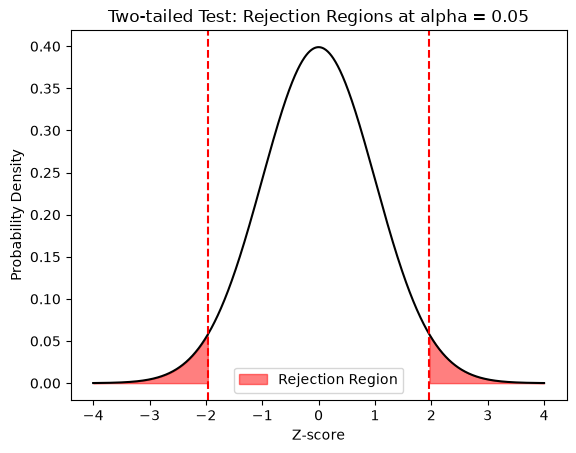

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)
alpha = 0.05
critical_value = stats.norm.ppf(1 - alpha/2)

plt.plot(x, y, color='black')
plt.fill_between(x, y, where=(x >= critical_value), color='red', alpha=0.5, label='Rejection Region')
plt.fill_between(x, y, where=(x <= -critical_value), color='red', alpha=0.5)
plt.axvline(critical_value, color='red', linestyle='dashed')
plt.axvline(-critical_value, color='red', linestyle='dashed')
plt.title("Two-tailed Test: Rejection Regions at alpha = 0.05")
plt.xlabel("Z-score")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

**Interpretation**: The red shaded areas represent the rejection regions at each tail; if a test statistic falls within these zones, the null hypothesis is rejected at the 5% significance level.

## Visualization 2 — Type I vs Type II Error (Overlapping Distributions)

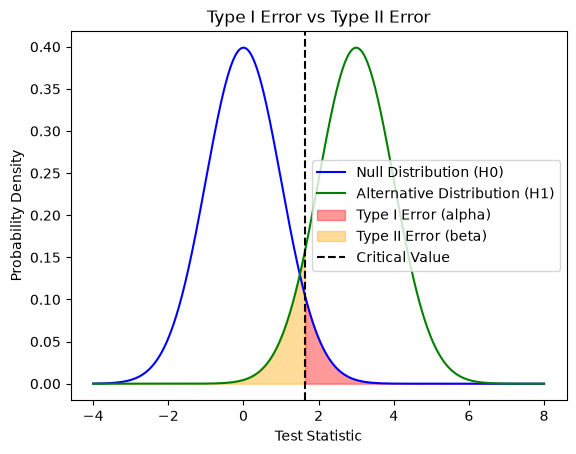

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-4, 8, 1000)
null_dist = stats.norm.pdf(x, 0, 1)
alt_dist = stats.norm.pdf(x, 3, 1)
critical_value = 1.645

plt.plot(x, null_dist, label='Null Distribution (H0)', color='blue')
plt.plot(x, alt_dist, label='Alternative Distribution (H1)', color='green')
plt.fill_between(x, null_dist, where=(x >= critical_value), color='red', alpha=0.4, label='Type I Error (alpha)')
plt.fill_between(x, alt_dist, where=(x <= critical_value), color='orange', alpha=0.4, label='Type II Error (beta)')
plt.axvline(critical_value, color='black', linestyle='dashed', label='Critical Value')
plt.title("Type I Error vs Type II Error")
plt.xlabel("Test Statistic")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

**Interpretation**: The red region shows the Type I error (falsely rejecting a true H0), while the orange region shows the Type II error (failing to reject a false H0) — visualizing the inherent trade-off between the two error types.

## Overall Advantages

- Provides a structured, objective framework for making data-driven decisions rather than relying on intuition
- Quantifies uncertainty through p-values and confidence intervals, giving a measure of confidence in conclusions
- Widely applicable across A/B testing, medical research, quality control, and ML model comparison
- Helps distinguish real effects from random noise in sample data

## Overall Limitations

- A statistically significant result doesn't always mean a practically or business-meaningful effect (statistical vs practical significance)
- p-values are often misinterpreted as the probability that the null hypothesis is true, which is incorrect
- Results depend heavily on sample size — very large samples can make trivial effects appear "significant"
- Choosing an inappropriate significance level or test type (one-tailed vs two-tailed) can lead to misleading conclusions

## Interview Questions

**1. What is the difference between the null hypothesis and the alternative hypothesis?**
The null hypothesis (H0) assumes there is no effect or difference in the population and represents the default position. The alternative hypothesis (H1) is the competing claim that there is a real effect or difference, which we accept only if there is sufficient evidence against H0.

**2. How do you interpret a p-value, and what is a common mistake people make when interpreting it?**
A p-value is the probability of observing a result as extreme as the sample result, assuming the null hypothesis is true — a smaller p-value means stronger evidence against H0. A common mistake is interpreting it as "the probability that the null hypothesis is true," which is incorrect; it only measures how surprising the data is under H0.

**3. What is the difference between a Type I error and a Type II error?**
A Type I error (false positive) occurs when we reject a true null hypothesis, concluding there's an effect when there isn't one, with probability equal to alpha. A Type II error (false negative) occurs when we fail to reject a false null hypothesis, missing a real effect that exists, with probability equal to beta.

**4. When would you use a one-tailed test instead of a two-tailed test?**
A one-tailed test is used when the research question predicts a specific direction of effect (e.g., "is the new method strictly better"), while a two-tailed test is used when we simply want to know if there's any difference at all, in either direction, without a directional assumption.

**5. What does a 95% confidence interval actually mean?**
It means that if we were to repeat the sampling process many times and construct a confidence interval each time, about 95% of those intervals would contain the true population parameter — it does not mean there's a 95% probability the true value lies in this one specific interval.

**6. What is the relationship between significance level, Type I error, and statistical power?**
The significance level (alpha) directly equals the probability of making a Type I error; lowering alpha reduces Type I error risk but increases Type II error risk (beta), which in turn lowers the test's power (1 − beta) — its ability to correctly detect a true effect. Choosing alpha involves balancing this trade-off based on the cost of each error type.

## Self-Reflection

Working through hypothesis testing clarified how statistical decision-making is fundamentally about managing uncertainty and trade-offs rather than proving something with absolute certainty. Understanding the relationship between Type I and Type II errors made it clear why choosing a significance level isn't just a default 0.05 setting, but a real decision that depends on the cost of being wrong in either direction. Learning the precise, often counterintuitive meaning of p-values and confidence intervals reinforced how easily these concepts get misinterpreted in real-world reporting and even in professional settings. Overall, this topic connected statistical theory directly to practical decisions in A/B testing and model comparison, showing how hypothesis testing forms the backbone of validating whether an observed improvement is real or just noise.
